In [48]:
import pandas as pd

#FACT: Call Activity Data Set - Dials(Call Activity Data Set 2026-02-).csv
calls = pd.read_csv('Call Activity Data Set - Dials(Call Activity Data Set 2026-02-).csv',
    parse_dates=[
        'Lead Created (ET) Time',
        'Activity (ET) Time'
    ])
print('CALLS: ',len(calls))

# Filter to direction = 'outbound'
calls = calls[calls['Direction'] == 'Outbound']
print('CALLS: ',len(calls))

# Remove records where lead create (et) time > activity (et) time
calls = calls[
    calls['Lead Created (ET) Time'] <= calls['Activity (ET) Time']
]
print('CALLS: ',len(calls))

# Calculate relative day
calls['seconds_since_creation'] = (
    calls['Activity (ET) Time'] - calls['Lead Created (ET) Time']
).dt.total_seconds()

calls['day_since_creation'] = (calls['seconds_since_creation'] // 86400) + 1
calls['day_since_creation'] = calls['day_since_creation'].astype(int)

#DIM: Lead(Sheet1).csv
leads = pd.read_csv(
    "DTC Leads Data Set - dim lead(Sheet1).csv",
    parse_dates=[
        'Lead Created (ET) Time',
        'Last Contact Attempt (ET) Time'
    ]
)

leads = leads[leads['Last Contact Attempt (ET) Time'].notna()]

# CONVERT cols to boolean
yes_no_columns = [
    'Contacted? (Yes / No)',
    'Is Live Transfer? (Yes / No)',
    'Is Latest Pool A Dial Attempt? (Yes / No)',
    'Is Latest Dial Attempt? (Yes / No)',
    'Is Pool A (Active SDR)? (Yes / No)',
    'Incoming Lead? (Yes / No)'
]

# Convert "Yes" → True, "No" → False (safe mapping)
for col in yes_no_columns:
    if col in calls.columns:
        calls[col] = calls[col].map({
            'Yes': True,
            'No': False
        }).astype('boolean')  # pandas nullable boolean type (keeps NaN)
    else:
        print(f"Column not found: {col}")

# Quick verification
print("\nPost-conversion summary:")
for col in yes_no_columns:
    if col in calls.columns:
        print(f"\n{col}:")
        print(calls[col].value_counts(dropna=False))
        print(f"  dtype: {calls[col].dtype}")

CALLS:  382454
CALLS:  363743
CALLS:  362980

Post-conversion summary:

Contacted? (Yes / No):
Contacted? (Yes / No)
False    344592
True      18388
Name: count, dtype: Int64
  dtype: boolean

Is Live Transfer? (Yes / No):
Is Live Transfer? (Yes / No)
False    358153
True       4827
Name: count, dtype: Int64
  dtype: boolean

Is Latest Pool A Dial Attempt? (Yes / No):
Is Latest Pool A Dial Attempt? (Yes / No)
False    337087
True      25893
Name: count, dtype: Int64
  dtype: boolean

Is Latest Dial Attempt? (Yes / No):
Is Latest Dial Attempt? (Yes / No)
False    337679
True      25301
Name: count, dtype: Int64
  dtype: boolean

Is Pool A (Active SDR)? (Yes / No):
Is Pool A (Active SDR)? (Yes / No)
True     291296
False     71684
Name: count, dtype: Int64
  dtype: boolean

Incoming Lead? (Yes / No):
Incoming Lead? (Yes / No)
False    362980
Name: count, dtype: Int64
  dtype: boolean


In [47]:
# import pandas as pd

# # Adjust filename if needed (e.g. if it's zipped/unzipped differently)
# FILE = 'Call Activity Data Set - Dials(Call Activity Data Set 2026-02-).csv'

# calls = pd.read_csv(FILE, 
#                     parse_dates=['Lead Created (ET) Time', 'Activity (ET) Time'],
#                     low_memory=False)   # helps if file is large/mixed types

# print(f"Total rows loaded: {len(calls):,}\n")

# # Basic column existence check
# pool_col = 'Pool A Call Attempt Number'
# if pool_col not in calls.columns:
#     print(f"ERROR: Column '{pool_col}' not found. Available columns:")
#     print(calls.columns.tolist())
# else:
#     print(f"Column '{pool_col}' exists. Summary:\n")

#     # Core diagnostics
#     print("Value counts (including NaN):")
#     print(calls[pool_col].value_counts(dropna=False).head(20))
#     print("… (showing top 20 most frequent values)\n")

#     print(f"Number of rows where {pool_col} is NOT null: {calls[pool_col].notna().sum():,}")
#     print(f"Percentage of rows with Pool A attempt number: {calls[pool_col].notna().mean()*100:.1f}%\n")

#     # Range for non-null values
#     non_null = calls[pool_col].dropna()
#     if len(non_null) > 0:
#         print("Among non-null Pool A attempt numbers:")
#         print(f"  Min   = {non_null.min()}")
#         print(f"  Max   = {non_null.max()}")
#         print(f"  Mean  = {non_null.mean():.2f}")
#         print(f"  Unique values count = {non_null.nunique()}\n")
#     else:
#         print("No non-null Pool A attempt numbers found.\n")

#     # Cross with Direction (very useful)
#     print("Cross-tab: Direction vs has Pool A attempt number")
#     print(pd.crosstab(
#         calls['Direction'].fillna('(missing)'),
#         calls[pool_col].notna().map({True: 'Has Pool A #', False: 'No Pool A #'}),
#         margins=True
#     ))

#     # Bonus: If there's also the boolean flag column
#     bool_col = 'Is Pool A (Active SDR)? (Yes / No)'
#     if bool_col in calls.columns:
#         print("\nCross-check with boolean Pool A flag:")
#         print(pd.crosstab(
#             calls[bool_col].fillna('(missing)'),
#             calls[pool_col].notna().map({True: 'Has #', False: 'No #'})
#         ))

In [49]:
# # 4. Restrict to first 5 days
calls = calls[calls['day_since_creation'].between(1, 5)].copy()
print(f"After restricting to days 1–5: {len(calls):,}")

# 5. Apply Pool A filter: attempt number 1–20 and not null
pool_col = 'Pool A Call Attempt Number'

mask_pool_a = (
    calls[pool_col].notna() &
    (calls[pool_col] >= 1) &
    (calls[pool_col] <= 20)
)

calls = calls[mask_pool_a].copy()

print(f"\nAfter Pool A attempt 1–20 filter: {len(calls):,}")
print(f"Rows removed by Pool A filter: {len(calls) - len(calls):,} wait no — previous was {len(calls):,} before this line, sorry")

# Final check: attempt number distribution should be 1–20 only
print("\nPool A attempt number distribution after filter:")
print(calls[pool_col].value_counts().sort_index())

# Optional: quick look at the first few rows
print("\nFirst 5 rows of cleaned & filtered data:")
print(calls.head(5)[['Lead ID', 'Activity (ET) Time', 'day_since_creation', pool_col, 'Contacted? (Yes / No)']])

After restricting to days 1–5: 186,075

After Pool A attempt 1–20 filter: 146,212
Rows removed by Pool A filter: 0 wait no — previous was 146,212 before this line, sorry

Pool A attempt number distribution after filter:
Pool A Call Attempt Number
1.0     23550
2.0     19033
3.0     17477
4.0     16401
5.0     15282
6.0     13842
7.0     12441
8.0     10622
9.0      7339
10.0     4673
11.0     2884
12.0     1603
13.0      755
14.0      242
15.0       61
16.0        7
Name: count, dtype: int64

First 5 rows of cleaned & filtered data:
              Lead ID  Activity (ET) Time  day_since_creation  \
0  00QPh00000kH72cMAC 2025-12-17 09:10:00                   1   
1  00QPh00000kH72cMAC 2025-12-17 12:15:00                   1   
2  00QPh00000kH72cMAC 2025-12-17 15:52:00                   1   
3  00QPh00000kH72cMAC 2025-12-18 09:43:00                   2   
4  00QPh00000kH72cMAC 2025-12-18 13:10:00                   2   

   Pool A Call Attempt Number  Contacted? (Yes / No)  
0              

In [53]:
# Option 1: use a list comprehension + concat (very explicit, rarely fails)
filtered_groups = []

for lead_id, group in calls.groupby('Lead ID'):
    group = group.sort_values('Activity (ET) Time')
    contacted_mask = group['Contacted? (Yes / No)'] == True
    
    if contacted_mask.any():
        first_idx = contacted_mask.idxmax()
        kept = group.loc[:first_idx]
    else:
        kept = group
    
    # important: add the lead_id back if needed (but since it's already in the group, usually not required)
    filtered_groups.append(kept)

calls_filtered = pd.concat(filtered_groups, ignore_index=True)

# Now test
print(f"Rows before:  {len(calls):,}")
print(f"Rows after:   {len(calls_filtered):,}")
print(f"Rows removed: {len(calls) - len(calls_filtered):,}")

print("\nUnique Lead IDs before:", calls['Lead ID'].nunique())
print("Unique Lead IDs after: ", calls_filtered['Lead ID'].nunique())

print("\nContacted distribution after:")
print(calls_filtered['Contacted? (Yes / No)'].value_counts(dropna=False))

Rows before:  146,212
Rows after:   138,308
Rows removed: 7,904

Unique Lead IDs before: 23552
Unique Lead IDs after:  23552

Contacted distribution after:
Contacted? (Yes / No)
False    131105
True       7203
Name: count, dtype: Int64


In [54]:
# How many leads have more than 1 successful contact in the FULL data (before filter)
multiple_contacts = calls[calls['Contacted? (Yes / No)'] == True].groupby('Lead ID').size()
print("Leads with multiple successful contacts (in original data):")
print(multiple_contacts[multiple_contacts > 1].value_counts().sort_index())

print(f"\nTotal leads with >1 contact: {len(multiple_contacts[multiple_contacts > 1])}")
print(f"Total extra True rows dropped due to this: {multiple_contacts[multiple_contacts > 1].sum() - len(multiple_contacts[multiple_contacts > 1])}")

# Same check after filtering (should be at most 1 per lead now)
post_filter_multi = calls_filtered[calls_filtered['Contacted? (Yes / No)'] == True].groupby('Lead ID').size()
print("\nAfter filtering — any leads still have >1 True?")
print(post_filter_multi[post_filter_multi > 1].sum())  # should be 0

Leads with multiple successful contacts (in original data):
2    589
3     66
4     10
Name: count, dtype: int64

Total leads with >1 contact: 665
Total extra True rows dropped due to this: 751

After filtering — any leads still have >1 True?
0


In [55]:
# Aggregate: number of attempts per lead per day
daily_attempts = (
    calls_filtered
    .groupby(['Lead ID', 'day_since_creation'])
    .size()
    .reset_index(name='attempts')
)

print("Sample of daily_attempts:")
print(daily_attempts.head(10))

print("\nShape of daily_attempts:", daily_attempts.shape)
print("Max attempts on any single day-lead:", daily_attempts['attempts'].max())

Sample of daily_attempts:
              Lead ID  day_since_creation  attempts
0  00QPh00000XK7qMMAT                   1         1
1  00QPh00000d75kUMAQ                   5         1
2  00QPh00000d78VSMAY                   5         1
3  00QPh00000d7ADwMAM                   5         1
4  00QPh00000d7KRnMAM                   5         1
5  00QPh00000d7L9LMAU                   5         1
6  00QPh00000d7O3xMAE                   5         1
7  00QPh00000d7OFGMA2                   5         1
8  00QPh00000d7REkMAM                   5         1
9  00QPh00000d7RrRMAU                   5         1

Shape of daily_attempts: (62055, 3)
Max attempts on any single day-lead: 6


In [56]:
# 1. Find first contact day per lead (min day where Contacted == True)
first_contact = (
    calls_filtered[calls_filtered['Contacted? (Yes / No)'] == True]
    .groupby('Lead ID')['day_since_creation']
    .min()
    .reset_index(name='first_contact_day')
)

# Merge back to all leads (left join so non-contacted get NaN)
all_leads = pd.DataFrame({'Lead ID': calls_filtered['Lead ID'].unique()})
lead_status = all_leads.merge(first_contact, on='Lead ID', how='left')

# Fill NaN with 6 (meaning never contacted in first 5 days)
lead_status['first_contact_day'] = lead_status['first_contact_day'].fillna(6).astype(int)

print("First contact day distribution:")
print(lead_status['first_contact_day'].value_counts().sort_index())

# 2. Create summary table for days 1-5
summary = []

for d in range(1, 6):
    # Eligible: first contact on/after d (or never)
    eligible = lead_status[lead_status['first_contact_day'] >= d]['Lead ID']
    n_eligible = len(eligible)
    
    # Get attempts on this day for eligible leads (fill 0 if no row)
    day_data = daily_attempts[daily_attempts['day_since_creation'] == d]
    attempts_today = (
        pd.Series(index=eligible, data=0, dtype=int)
        .add(
            day_data.set_index('Lead ID')['attempts'].reindex(eligible).fillna(0),
            fill_value=0
        )
    )
    
    # Bucket counts
    counts = attempts_today.value_counts().sort_index()
    
    row = {
        'day': d,
        'eligible_leads': n_eligible,
        'attempts_0': counts.get(0, 0),
        'attempts_1': counts.get(1, 0),
        'attempts_2': counts.get(2, 0),
        'attempts_3': counts.get(3, 0),
        'attempts_>3': attempts_today[attempts_today > 3].count()
    }
    summary.append(row)

summary_df = pd.DataFrame(summary)

print("\nDaily attempt summary (eligible leads & buckets):")
print(summary_df)

# Quick percentages for reaching exactly 3
summary_df['pct_reach_3'] = (summary_df['attempts_3'] / summary_df['eligible_leads'] * 100).round(1)
print("\nWith % reaching exactly 3 attempts:")
print(summary_df[['day', 'eligible_leads', 'attempts_3', 'pct_reach_3']])

First contact day distribution:
first_contact_day
1     5262
2      854
3      472
4      333
5      282
6    16349
Name: count, dtype: int64

Daily attempt summary (eligible leads & buckets):
   day  eligible_leads  attempts_0  attempts_1  attempts_2  attempts_3  \
0    1           23552        1564        6324        4274        7190   
1    2           18290        5826        3106        4183        4915   
2    3           17436        7381        2778        4039        3112   
3    4           16964        8124        2717        3049        2957   
4    5           16631        7923        2190        3340        3109   

   attempts_>3  
0         4200  
1          260  
2          126  
3          117  
4           69  

With % reaching exactly 3 attempts:
   day  eligible_leads  attempts_3  pct_reach_3
0    1           23552        7190         30.5
1    2           18290        4915         26.9
2    3           17436        3112         17.8
3    4           16964        2

In [57]:
# Add hour of day (0-23) in ET
calls_filtered['hour_of_day'] = calls_filtered['Activity (ET) Time'].dt.hour

print("Overall attempt hour distribution (0-23):")
print(calls_filtered['hour_of_day'].value_counts().sort_index())

print("\nAttempts per hour, split by day_since_creation:")
hour_by_day = calls_filtered.groupby(['day_since_creation', 'hour_of_day']).size().unstack(fill_value=0)
print(hour_by_day)

# Quick summary stats
print("\nAverage attempts per lead per day (recap):")
print(calls_filtered.groupby(['Lead ID', 'day_since_creation']).size().groupby('day_since_creation').mean())

print("\n% of attempts happening in common business hours windows:")
print("Before 9am:   ", (calls_filtered['hour_of_day'] < 9).mean() * 100)
print("9am-5pm:      ", ((calls_filtered['hour_of_day'] >= 9) & (calls_filtered['hour_of_day'] < 17)).mean() * 100)
print("5pm-8pm:      ", ((calls_filtered['hour_of_day'] >= 17) & (calls_filtered['hour_of_day'] < 20)).mean() * 100)
print("After 8pm:    ", (calls_filtered['hour_of_day'] >= 20).mean() * 100)

Overall attempt hour distribution (0-23):
hour_of_day
8      7762
9     19134
10    14451
11    12810
12    15890
13    13784
14    14955
15    13704
16    13888
17     7653
18     4259
19       18
Name: count, dtype: int64

Attempts per hour, split by day_since_creation:
hour_of_day           8     9     10    11    12    13    14    15    16  \
day_since_creation                                                         
1                   4315  7734  3759  5540  6995  4898  5028  6335  4127   
2                   1239  3986  3299  1954  3233  2821  2552  2882  3308   
3                    844  2523  2777  2001  1899  2276  2598  1600  2318   
4                    784  2540  2097  1616  2016  1897  2221  1452  2103   
5                    580  2351  2519  1699  1747  1892  2556  1435  2032   

hour_of_day           17    18  19  
day_since_creation                  
1                   2776  2205  14  
2                   1215   766   3  
3                   1446   413   1  
4        

In [58]:
import pandas as pd

# Only keep rows where we have multiple attempts possible (group by lead + day)
multi_attempt_days = calls_filtered.groupby(['Lead ID', 'day_since_creation']).filter(lambda x: len(x) >= 2)

if len(multi_attempt_days) == 0:
    print("No days with 2+ attempts — nothing to compute.")
else:
    # Sort within each lead-day group
    multi_attempt_days = multi_attempt_days.sort_values(['Lead ID', 'day_since_creation', 'Activity (ET) Time'])

    # Compute time delta to previous attempt (in minutes)
    multi_attempt_days['time_since_prev'] = multi_attempt_days.groupby(['Lead ID', 'day_since_creation'])['Activity (ET) Time'].diff().dt.total_seconds() / 60

    # Drop the first row in each group (no previous)
    gaps = multi_attempt_days['time_since_prev'].dropna()

    print(f"Number of inter-attempt gaps calculated: {len(gaps):,}")
    print(f"Number of lead-day groups with 2+ attempts: {multi_attempt_days['Lead ID'].nunique():,} unique leads contributing")

    # Summary stats (in minutes)
    print("\nTime gaps between consecutive attempts (minutes):")
    print(gaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))

    # % of gaps < 4 hours (240 minutes), < 3 hours, etc.
    print("\nPercentage of gaps:")
    print(f"  < 60 min:   {(gaps < 60).mean() * 100:.1f}%")
    print(f"  < 180 min:  {(gaps < 180).mean() * 100:.1f}%")
    print(f"  < 240 min:  {(gaps < 240).mean() * 100:.1f}%")   # < 4 hours
    print(f"  >= 240 min: {(gaps >= 240).mean() * 100:.1f}%")

    # Optional: by day_since_creation
    print("\nMedian gap by day_since_creation:")
    print(multi_attempt_days.groupby('day_since_creation')['time_since_prev'].median().round(1))

Number of inter-attempt gaps calculated: 76,253
Number of lead-day groups with 2+ attempts: 17,940 unique leads contributing

Time gaps between consecutive attempts (minutes):
count    76253.0
mean       394.8
std        355.3
min          0.0
5%         183.0
25%        197.0
50%        214.0
75%        283.0
95%       1110.0
max       1439.0
Name: time_since_prev, dtype: float64

Percentage of gaps:
  < 60 min:   2.3%
  < 180 min:  2.4%
  < 240 min:  67.0%
  >= 240 min: 33.0%

Median gap by day_since_creation:
day_since_creation
1    205.0
2    217.0
3    220.0
4    218.0
5    222.0
Name: time_since_prev, dtype: float64


In [59]:
# 1. Get only the non-contacted leads
non_contacted_leads = lead_status[lead_status['first_contact_day'] == 6]['Lead ID']

print(f"Non-contacted leads: {len(non_contacted_leads):,}")

# 2. For these leads, find the MAX Pool A attempt number they reached
max_attempts_non_contacted = (
    calls_filtered[calls_filtered['Lead ID'].isin(non_contacted_leads)]
    .groupby('Lead ID')['Pool A Call Attempt Number']
    .max()
    .reset_index(name='max_attempt_reached')
)

# Quick check
print("\nSummary of max attempt reached (non-contacted leads):")
print(max_attempts_non_contacted['max_attempt_reached'].describe().round(1))

# 3. Build the table: count & % per max attempt value
table = (
    max_attempts_non_contacted
    ['max_attempt_reached']
    .value_counts()
    .sort_index()
    .reset_index(name='count')
)

table['pct'] = (table['count'] / table['count'].sum() * 100).round(1)
table['cumulative_pct'] = table['pct'].cumsum().round(1)

# Rename for clarity
table = table.rename(columns={'max_attempt_reached': 'max_attempt'})

print("\nTable: Where did we typically stop for non-contacted leads?")
print(table)

# Optional: median / mean / mode for quick talking points
median_stop = max_attempts_non_contacted['max_attempt_reached'].median()
mean_stop = max_attempts_non_contacted['max_attempt_reached'].mean().round(1)
print(f"\nMedian max attempt reached: {median_stop}")
print(f"Mean max attempt reached:   {mean_stop}")

Non-contacted leads: 16,349

Summary of max attempt reached (non-contacted leads):
count    16349.0
mean         7.4
std          3.3
min          1.0
25%          5.0
50%          8.0
75%         10.0
max         16.0
Name: max_attempt_reached, dtype: float64

Table: Where did we typically stop for non-contacted leads?
    max_attempt  count   pct  cumulative_pct
0           1.0   1497   9.2             9.2
1           2.0    608   3.7            12.9
2           3.0    466   2.9            15.8
3           4.0    624   3.8            19.6
4           5.0   1011   6.2            25.8
5           6.0   1043   6.4            32.2
6           7.0   1505   9.2            41.4
7           8.0   2978  18.2            59.6
8           9.0   2409  14.7            74.3
9          10.0   1594   9.7            84.0
10         11.0   1166   7.1            91.1
11         12.0    758   4.6            95.7
12         13.0    458   2.8            98.5
13         14.0    173   1.1            99.6
14 

In [60]:
# 1. Get all attempts for non-contacted leads
non_contact_attempts = calls_filtered[calls_filtered['Lead ID'].isin(non_contacted_leads)]

# 2. Find the LAST attempt per lead (latest Activity Time)
last_attempt = (
    non_contact_attempts
    .loc[non_contact_attempts.groupby('Lead ID')['Activity (ET) Time'].idxmax()]
    .reset_index(drop=True)
)

print(f"Last attempts found: {len(last_attempt):,} (should match non-contacted leads count)")

# 3. Aggregate by Outcome
outcome_table = (
    last_attempt['Outcome']
    .value_counts(dropna=False)
    .reset_index(name='count')
    .rename(columns={'index': 'Outcome'})
)

outcome_table['pct'] = (outcome_table['count'] / outcome_table['count'].sum() * 100).round(1)

# Sort by count descending for readability
outcome_table = outcome_table.sort_values('count', ascending=False).reset_index(drop=True)

print("\nOutcome of the LAST attempt for non-contacted leads:")
print(outcome_table)

Last attempts found: 16,349 (should match non-contacted leads count)

Outcome of the LAST attempt for non-contacted leads:
                                              Outcome  count   pct
0                                           No Answer  14739  90.2
1                              Bad/Disconnected Phone    442   2.7
2                                      Left Voicemail    355   2.2
3                                          Add to DNC    260   1.6
4                                Nurture - No Benefit    209   1.3
5                                             Hung Up    123   0.8
6                  Nurture - Went With Another Lender     65   0.4
7                                 Fake Lead/Fake Data     62   0.4
8                                              Redial     45   0.3
9                                     Appointment Set     27   0.2
10                     Nurture - Communication Issues     12   0.1
11                                      Transfer Sent      5   0.0
12    

In [61]:
# Assuming:
# leads = your dim_lead dataframe (with 'Lead ID', 'Number of Opportunities')
# calls_filtered = the filtered call activity df we built earlier

# 1. Leads that have at least one Opportunity according to dim_lead
opp_leads_from_dim = leads[leads['Number of Opportunities'] >= 1]['Lead ID'].unique()
print(f"Leads with Number of Opportunities >= 1: {len(opp_leads_from_dim):,}")

# 2. Leads that have at least one live transfer / transfer sent / appointment in calls
# (adjust outcome names if needed after you see unique outcomes)
opportunity_outcomes = ['Transfer Sent', 'Appointment Set', 'Is Live Transfer?']  # we'll check patterns

has_opp_in_calls = calls_filtered[
    (calls_filtered['Is Live Transfer? (Yes / No)'] == True) |
    (calls_filtered['Outcome'].isin(['Transfer Sent', 'Appointment Set', 'Live Transfer']))
]['Lead ID'].unique()

print(f"Leads with at least one clear opportunity outcome in calls: {len(has_opp_in_calls):,}")

# 3. Overlap check
overlap = set(opp_leads_from_dim) & set(has_opp_in_calls)
only_in_dim = set(opp_leads_from_dim) - set(has_opp_in_calls)
only_in_calls = set(has_opp_in_calls) - set(opp_leads_from_dim)

print(f"\nOverlap (both sources agree): {len(overlap):,}")
print(f"Only in dim_lead (Number of Opportunities >0 but no matching call outcome): {len(only_in_dim):,}")
print(f"Only in calls (have transfer/outcome but Number of Opportunities =0): {len(only_in_calls):,}")

# 4. Quick look at outcomes that actually created opportunities
print("\nTop outcomes among calls that are marked as live transfer / transfer sent:")
print(
    calls_filtered[
        (calls_filtered['Is Live Transfer? (Yes / No)'] == True) |
        (calls_filtered['Outcome'].str.contains('Transfer|Appointment|Live', case=False, na=False))
    ]['Outcome'].value_counts().head(10)
)

Leads with Number of Opportunities >= 1: 8,756
Leads with at least one clear opportunity outcome in calls: 4,154

Overlap (both sources agree): 3,413
Only in dim_lead (Number of Opportunities >0 but no matching call outcome): 5,343
Only in calls (have transfer/outcome but Number of Opportunities =0): 741

Top outcomes among calls that are marked as live transfer / transfer sent:
Outcome
Transfer Sent                     2868
Appointment Set                   1294
Calendly Appointment Confirmed       2
No Answer                            1
Left Voicemail                       1
Add to DNC                           1
Name: count, dtype: int64


In [62]:
# Get Lead IDs that have Opportunity in dim_lead
opp_lead_ids = leads[leads['Number of Opportunities'] >= 1]['Lead ID'].unique()

# Filter calls to successful contacts for those leads only
opp_success_calls = calls_filtered[
    (calls_filtered['Lead ID'].isin(opp_lead_ids)) &
    (calls_filtered['Contacted? (Yes / No)'] == True)
]

print(f"Successful contacts for Opportunity-flagged leads: {len(opp_success_calls):,}")

print("\nTop 15 Outcomes on successful contacts (for leads with Number of Opportunities >= 1):")
print(opp_success_calls['Outcome'].value_counts(dropna=False).head(15))

print("\nPercentage breakdown (top 5):")
top5 = opp_success_calls['Outcome'].value_counts(normalize=True).head(5) * 100
print(top5.round(1).to_string())

Successful contacts for Opportunity-flagged leads: 4,000

Top 15 Outcomes on successful contacts (for leads with Number of Opportunities >= 1):
Outcome
Transfer Sent                                                    2837
Appointment Set                                                   545
Hold Time Exceeded                                                302
Hung Up                                                           215
Redial                                                             27
Nurture - Income                                                   13
Nurture - Credit Score                                             11
Nurture - Went With Another Lender                                 11
Nurture - No Benefit                                               10
Add to DNC                                                          7
Nurture - Loan Amount Under 100k                                    6
Nurture - No Down Payment / Assets - Plan to Save Up                6
Nurture 

In [63]:
trigger_mask = (
    (calls_filtered['Outcome'] == 'Transfer Sent') |
    (calls_filtered['Outcome'] == 'Appointment Set') |
    (calls_filtered['Is Live Transfer? (Yes / No)'] == True)
)

trigger_leads = calls_filtered[trigger_mask]['Lead ID'].unique()

print(f"Leads with at least one direct Opportunity trigger (Transfer/Appointment/Live Transfer): {len(trigger_leads):,}")

print("\nHow many of these are also flagged in dim_lead as having Opportunities?")
overlap_trigger = set(trigger_leads) & set(opp_lead_ids)
print(f"Overlap with Number of Opportunities >=1: {len(overlap_trigger):,}")

print("\nTop outcomes among trigger rows:")
print(calls_filtered[trigger_mask]['Outcome'].value_counts(dropna=False))

Leads with at least one direct Opportunity trigger (Transfer/Appointment/Live Transfer): 4,154

How many of these are also flagged in dim_lead as having Opportunities?
Overlap with Number of Opportunities >=1: 3,413

Top outcomes among trigger rows:
Outcome
Transfer Sent      2868
Appointment Set    1294
No Answer             1
Left Voicemail        1
Add to DNC            1
Name: count, dtype: int64


In [64]:
# Define the trigger condition (same as above)
trigger_mask = (
    (calls_filtered['Outcome'] == 'Transfer Sent') |
    (calls_filtered['Outcome'] == 'Appointment Set') |
    (calls_filtered['Is Live Transfer? (Yes / No)'] == True)
)

# Get only the trigger rows
trigger_rows = calls_filtered[trigger_mask].copy()

# Per lead: earliest attempt number that had a trigger
first_trigger_attempt = (
    trigger_rows
    .groupby('Lead ID')['Pool A Call Attempt Number']
    .min()
    .reset_index(name='first_trigger_attempt')
)

print(f"Leads with a first trigger attempt: {len(first_trigger_attempt):,}")

# Distribution table
dist_table = (
    first_trigger_attempt['first_trigger_attempt']
    .value_counts()
    .sort_index()
    .reset_index(name='count')
)

dist_table['pct'] = (dist_table['count'] / dist_table['count'].sum() * 100).round(1)
dist_table['cumulative_pct'] = dist_table['pct'].cumsum().round(1)

dist_table = dist_table.rename(columns={'first_trigger_attempt': 'attempt_number'})

print("\nDistribution: Attempt number of FIRST Opportunity trigger")
print(dist_table)

# Summary stats
print(f"\nMedian attempt # for first trigger: {first_trigger_attempt['first_trigger_attempt'].median()}")
print(f"Mean attempt # for first trigger:   {first_trigger_attempt['first_trigger_attempt'].mean().round(1)}")
print(f"% within first 3 attempts:          {(dist_table[dist_table['attempt_number'] <= 3]['pct'].sum()):.1f}%")
print(f"% within first 5 attempts:          {(dist_table[dist_table['attempt_number'] <= 5]['pct'].sum()):.1f}%")

Leads with a first trigger attempt: 4,154

Distribution: Attempt number of FIRST Opportunity trigger
    attempt_number  count   pct  cumulative_pct
0              1.0   2527  60.8            60.8
1              2.0    588  14.2            75.0
2              3.0    340   8.2            83.2
3              4.0    213   5.1            88.3
4              5.0    154   3.7            92.0
5              6.0    121   2.9            94.9
6              7.0     90   2.2            97.1
7              8.0     55   1.3            98.4
8              9.0     38   0.9            99.3
9             10.0      7   0.2            99.5
10            11.0     10   0.2            99.7
11            12.0      5   0.1            99.8
12            13.0      5   0.1            99.9
13            14.0      1   0.0            99.9

Median attempt # for first trigger: 1.0
Mean attempt # for first trigger:   2.1
% within first 3 attempts:          83.2%
% within first 5 attempts:          92.0%


In [65]:
# ── First contact attempt per lead ──────────────────────────────────────────
contact_mask = calls_filtered['Contacted? (Yes / No)'] == True

first_contact = (
    calls_filtered[contact_mask]
    .groupby('Lead ID')['Pool A Call Attempt Number']
    .min()
    .reset_index(name='first_contact_attempt')
)

print(f"Leads ever contacted: {len(first_contact):,}")

# ── First opportunity trigger attempt per lead ──────────────────────────────
trigger_mask = (
    (calls_filtered['Outcome'] == 'Transfer Sent') |
    (calls_filtered['Outcome'] == 'Appointment Set') |
    (calls_filtered['Is Live Transfer? (Yes / No)'] == True)
)

first_opp = (
    calls_filtered[trigger_mask]
    .groupby('Lead ID')['Pool A Call Attempt Number']
    .min()
    .reset_index(name='first_opp_attempt')
)

print(f"Leads with at least one opportunity trigger: {len(first_opp):,}")

# ── Combine into one summary table ──────────────────────────────────────────
attempt_summary = pd.DataFrame({'Lead ID': calls_filtered['Lead ID'].unique()})

attempt_summary = attempt_summary.merge(
    first_contact, on='Lead ID', how='left'
).merge(
    first_opp, on='Lead ID', how='left'
)

print("\nSample of attempt_summary (first 10 rows):")
print(attempt_summary.head(10))

print("\nQuick counts:")
print(attempt_summary.notna().sum())

Leads ever contacted: 7,203
Leads with at least one opportunity trigger: 4,154

Sample of attempt_summary (first 10 rows):
              Lead ID  first_contact_attempt  first_opp_attempt
0  00QPh00000XK7qMMAT                    1.0                NaN
1  00QPh00000d75kUMAQ                    NaN                NaN
2  00QPh00000d78VSMAY                    NaN                NaN
3  00QPh00000d7ADwMAM                    NaN                NaN
4  00QPh00000d7KRnMAM                    NaN                NaN
5  00QPh00000d7L9LMAU                    NaN                NaN
6  00QPh00000d7O3xMAE                    NaN                NaN
7  00QPh00000d7OFGMA2                    NaN                NaN
8  00QPh00000d7REkMAM                    NaN                NaN
9  00QPh00000d7RrRMAU                    NaN                NaN

Quick counts:
Lead ID                  23552
first_contact_attempt     7203
first_opp_attempt         4154
dtype: int64


In [66]:
# Merge Lead Channel Segment into attempt_summary
# (assuming 'Lead ID' is the common key and exists in both)
attempt_summary_with_segment = attempt_summary.merge(
    leads[['Lead ID', 'Lead Channel Segment']],
    on='Lead ID',
    how='left'
)

print(f"Rows after merge: {len(attempt_summary_with_segment):,}")
print("Missing segments:", attempt_summary_with_segment['Lead Channel Segment'].isna().sum())

# Quick check unique segments
print("\nUnique Lead Channel Segments:")
print(attempt_summary_with_segment['Lead Channel Segment'].value_counts(dropna=False))

# ── Dataset for first contact ───────────────────────────────────────────────
contact_df = attempt_summary_with_segment[
    attempt_summary_with_segment['first_contact_attempt'].notna()
].copy()

print(f"\nLeads with first contact (for density): {len(contact_df):,}")

# ── Dataset for first opportunity trigger ────────────────────────────────────
opp_df = attempt_summary_with_segment[
    attempt_summary_with_segment['first_opp_attempt'].notna()
].copy()

print(f"Leads with first opp trigger (for density): {len(opp_df):,}")

# Basic summary stats per segment - first contact
print("\nMedian & Mean first_contact_attempt by Lead Channel Segment:")
contact_stats = contact_df.groupby('Lead Channel Segment')['first_contact_attempt'].agg(['count', 'median', 'mean']).round(2)
print(contact_stats.sort_values('count', ascending=False))

# Same for opportunity trigger
print("\nMedian & Mean first_opp_attempt by Lead Channel Segment:")
opp_stats = opp_df.groupby('Lead Channel Segment')['first_opp_attempt'].agg(['count', 'median', 'mean']).round(2)
print(opp_stats.sort_values('count', ascending=False))

Rows after merge: 23,552
Missing segments: 2

Unique Lead Channel Segments:
Lead Channel Segment
Digital Buy Partner    10763
Movoto                  6914
Paid Spend              3926
Direct / Organic        1827
Other                    111
Retargeting                9
NaN                        2
Name: count, dtype: int64

Leads with first contact (for density): 7,203
Leads with first opp trigger (for density): 4,154

Median & Mean first_contact_attempt by Lead Channel Segment:
                      count  median  mean
Lead Channel Segment                     
Movoto                 3152     1.0  2.43
Digital Buy Partner    1924     2.0  2.68
Paid Spend             1428     1.0  2.09
Direct / Organic        646     1.0  2.06
Other                    45     1.0  1.82
Retargeting               8     1.0  1.12

Median & Mean first_opp_attempt by Lead Channel Segment:
                      count  median  mean
Lead Channel Segment                     
Movoto                 1433     1.0  

C:\Users\giova\AppData\Local\Temp\ipykernel_46992\1503819943.py:34: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(
C:\Users\giova\AppData\Local\Temp\ipykernel_46992\1503819943.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


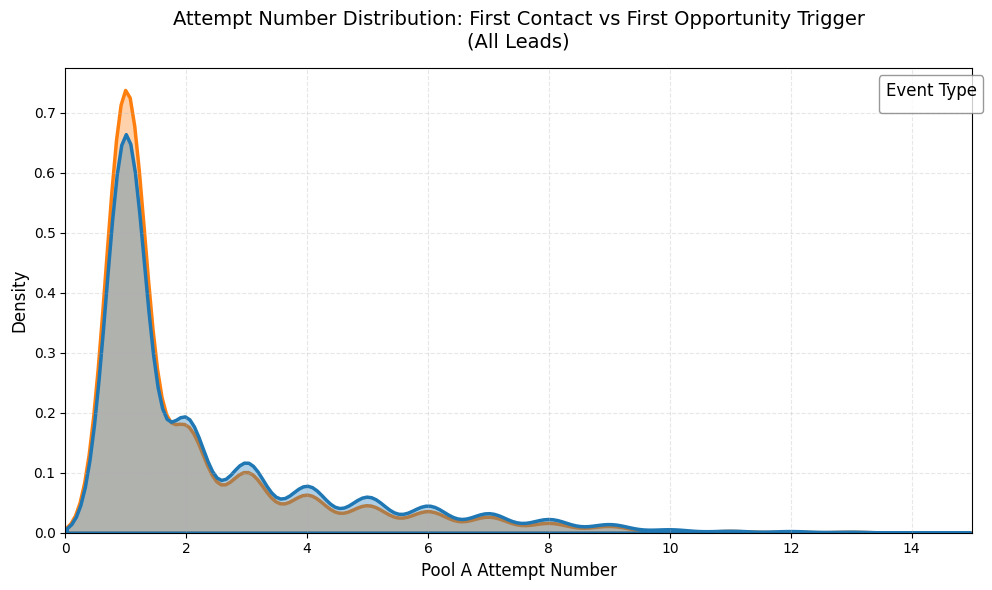

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# If 'melted' is not in memory anymore, re-create it quickly
melted = attempt_summary_with_segment.melt(
    id_vars=['Lead ID', 'Lead Channel Segment'],
    value_vars=['first_contact_attempt', 'first_opp_attempt'],
    var_name='metric',
    value_name='attempt_number'
).dropna(subset=['attempt_number'])

melted['metric'] = melted['metric'].replace({
    'first_contact_attempt': 'First Contact',
    'first_opp_attempt': 'First Opportunity Trigger'
})

# ── Plot with explicit legend fix ───────────────────────────────────────────
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=melted,
    x='attempt_number',
    hue='metric',
    fill=True,
    alpha=0.35,
    linewidth=2.5,
    common_norm=False,
    bw_adjust=0.9,
    palette=['#1f77b4', '#ff7f0e']  # blue → contact, orange → opportunity
)

# Force legend with custom labels and title
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=['First Contact', 'First Opportunity Trigger'],
    title='Event Type',
    loc='upper right',
    bbox_to_anchor=(1.02, 1),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    edgecolor='gray'
)

plt.title('Attempt Number Distribution: First Contact vs First Opportunity Trigger\n(All Leads)', fontsize=14, pad=15)
plt.xlabel('Pool A Attempt Number', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save for deck
plt.savefig('fig4_overall_density_fixed_legend.png', dpi=300, bbox_inches='tight')
plt.show()

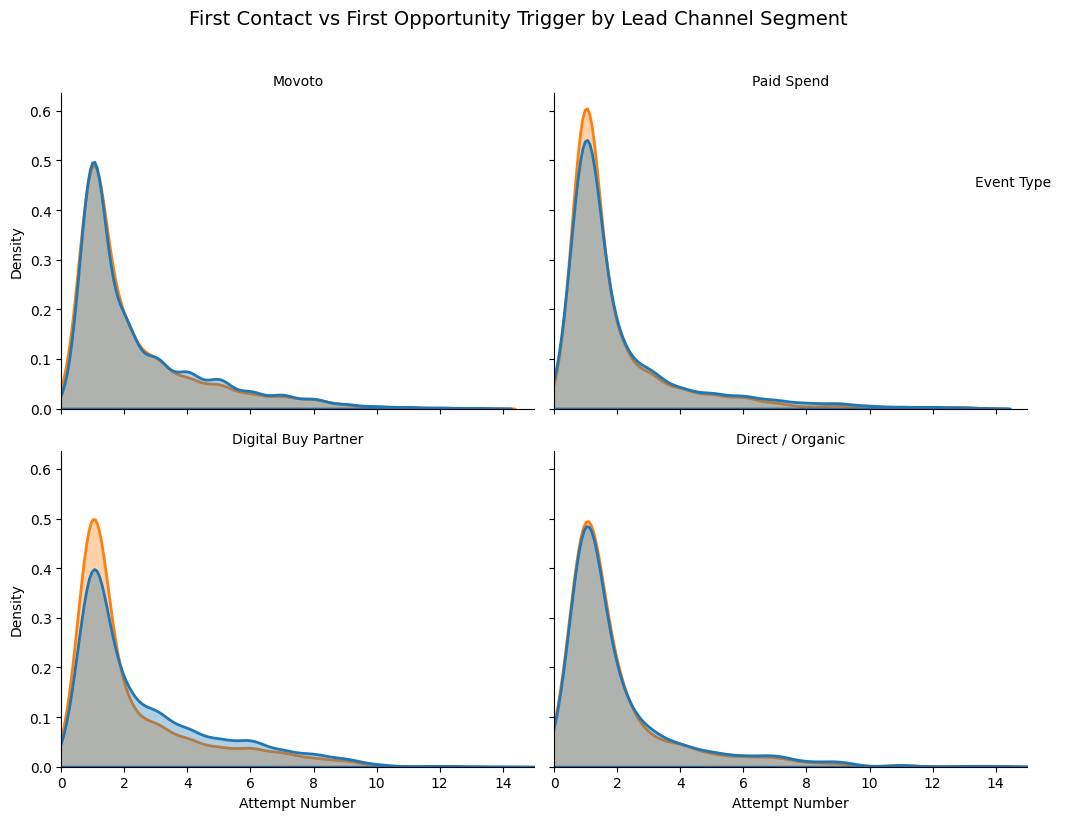

In [70]:
# Facet by Lead Channel Segment (only major ones for readability)
major_segments = ['Digital Buy Partner', 'Movoto', 'Paid Spend', 'Direct / Organic']

facet_data = melted[melted['Lead Channel Segment'].isin(major_segments)]

g = sns.FacetGrid(
    facet_data,
    col='Lead Channel Segment',
    col_wrap=2,
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.kdeplot,
    x='attempt_number',
    hue='metric',
    fill=True,
    alpha=0.35,
    linewidth=2,
    common_norm=False,
    palette=['#1f77b4', '#ff7f0e']
)

g.set_titles('{col_name}')
g.set_axis_labels('Attempt Number', 'Density')
g.set(xlim=(0, 15))
g.add_legend(title='Event Type', bbox_to_anchor=(1.02, 0.8))

plt.suptitle('First Contact vs First Opportunity Trigger by Lead Channel Segment', y=1.02, fontsize=14)
plt.tight_layout()

plt.savefig('fig4_segment_faceted.png', dpi=300, bbox_inches='tight')
plt.show()